# Projeto 2 - Ciencia dos Dados

### --- Grupo 6 ---

##### - João Victor Ribeiro Lopes
##### - Victor Lucius
##### - Alline Oliveira
##### - Isaac Reis
___


Importando Bibliotecas:

In [67]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import os

In [2]:
print('Esperamos trabalhar no diretório')
print(os.getcwd())

Esperamos trabalhar no diretório
c:\Users\victo\projeto2 cdados


___

# 1 - Introdução 

O Exame Nacional do Ensino Médio (ENEM) foi instituído em 1998 com o objetivo de avaliar o desempenho escolar dos estudantes ao término da educação básica. Em 2009, o exame aperfeiçoou sua metodologia e consolidou-se como o principal mecanismo de acesso à educação superior no Brasil. No entanto, para entender o ENEM em sua totalidade, é preciso enxergá-lo não apenas como uma prova de 180 questões e uma redação, mas como um mecanismo complexo que reflete a realidade social do Brasil, na qual indicadores socioeconômicos, demográficos e geográficos impactam profundamente a média final do participante.

Condições socioeconômicas de estudantes que concorrem ao Enem afetam em até 85% o resultado final no exame. É o que mostra estudo desenvolvido pelo cientista de dados e mestre em Economia pela Universidade de Brasília, Leonardo Sales. A pesquisa leva em contas fatores como a renda de cada aluno, se a escola é pública ou privada e se a família incentiva ou não os estudos.
UFMG, 8 nov. 2018. Disponível em: https://www3.ufmg.br/comunicacao/noticias/fatores-socioeconomicos-determinam-nota-do-enem-diz-estudo. Acesso em: 20 abr. 2026. 

Essa reflexão se torna ainda mais urgente quando observamos cursos de altíssima concorrência, como *Direito. Nesses cenários, a aprovação no SiSU exige uma excelência direcionada, pois a nota de corte é definida por uma **média ponderada* — atribuindo peso máximo (3) às áreas de Redação, Linguagens e Ciências Humanas, e peso menor (1) para Matemática e Ciências da Natureza. Com essa métrica, cada décimo na nota final é decisivo, evidenciando que o desempenho do candidato raramente é fruto apenas do seu esforço individual, mas sim do ambiente e das oportunidades que o cercam.

Neste projeto, adicionamos a essa equação um fator histórico sem precedentes: o ano de *2020, que marcou o ápice da pandemia de COVID-19 e escancarou a desigualdade na educação básica brasileira. Em contraste, analisamos **2023*, que representa o cenário de retomada pós-pandêmica.

Para o desenvolvimento deste projeto, utilizamos a análise de microdados, que representam um nível mais  detalhado de um levantamento estatístico. Enquanto dados agregados oferecem apenas visões generalistas, os microdados permitem acessar a unidade individual da pesquisa: no caso do ENEM, cada linha da base de dados corresponde às respostas e ao desempenho específico de um único candidato.
Essa escala de detalhamento é fundamental, pois possibilita a filtragem do público-alvo desejado. Além disso, os microdados são a base para o cálculo da Média Ponderada do ENEM (MPE), que atua como a nossa variável principal (target) e também é possível usufruir da análise de indicadores macroeconômicos na qual permite investigar se o contexto econômico e social onde o aluno vive e estuda impacta diretamente o seu desempenho e suas chances de ingresso em cursos de alta concorrência. Foi utilizado o  PIB Municipal que representa a soma de todos os bens e serviços finais produzidos em um município. Ele funciona como um termômetro da riqueza da cidade onde a escola do candidato está localizada e Índice FIRJAN que  acompanha anualmente o desenvolvimento humano, econômico e social das cidades com base em três pilares fundamentais: emprego, renda, educação e saúde.

Nosso objetivo é responder a uma pergunta central: *Até que ponto os indicadores macroeconômicos de um município e os dados socioeconômicos do candidato conseguem prever a sua Nota Ponderada para o curso de Direito no ENEM?*

# 2 - EXPORTANDO DADOS

Os dados sobre o ENEM foram retirados do INEP, os dados apresentam formato CSV e são acompanhados por um dicionário, já que algumas informações são substituídas por códigos para deixar as bases de dados mais leves. Os dados do desenvolvimento municipal FIRJAN foram retirados do site oficial do FIRJAN em formato CSV, os dados do PIB foram extraídos do IBGE, formato xlsx.

In [3]:
# Carregando os dados
enem2023 = pd.read_csv('./microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv',encoding='ISO-8859-1',sep=';')

In [4]:
print(f'Número de linhas: {enem2023.shape[0]}\nNúmero de colunas: {enem2023.shape[1]}')

Número de linhas: 3933955
Número de colunas: 76


In [5]:
enem2020 = pd.read_csv('./microdados_enem_2020/DADOS/MICRODADOS_ENEM_2020.csv',encoding='ISO-8859-1',sep=';')

In [6]:
print(f'Número de linhas: {enem2020.shape[0]}\nNúmero de colunas: {enem2020.shape[1]}')

Número de linhas: 5783109
Número de colunas: 76


In [7]:
firjan = pd.read_csv('Serie-Historica-IFDM-2013-a-2023(IFDM Geral).csv',encoding='ISO-8859-1',sep=';')

In [8]:
print(f'Número de linhas: {firjan.shape[0]}\nNúmero de colunas: {firjan.shape[1]}')

Número de linhas: 5570
Número de colunas: 36


In [9]:
pib = pd.read_excel('PIB dos Municípios - base de dados 2010-2023.xlsx')

In [10]:
print(f'Número de linhas: {pib.shape[0]}\nNúmero de colunas: {pib.shape[1]}')

Número de linhas: 77965
Número de colunas: 43


In [11]:
dicionario2023 = pd.read_excel('./microdados_enem_2023/DICIONÁRIO/Dicionário_Microdados_Enem_2023.xlsx')

In [12]:
dicionario2020 = pd.read_excel('./microdados_enem_2020/DICIONÁRIO/Dicionário_Microdados_Enem_2020.xlsx')

# FILTRANDO DADOS

Primeiro, excluímos as linhas que dificultariam a análise: Treineiros, Faltou em alguma prova, redação irregular (receberam 0), que não estavam concluindo o ensino médio no ano, não eram brasileiros, ensino não convencional (Educação Especial - Modalidade Substitutiva), não responderam o município onde estudaram, não responderam o questionário socioeconômico. Depois, excluímos as colunas de pouca relevância: Todos que já foram filtrados para um único valor, respostas na prova, gabarito, nota indivídual da redação, código da prova...

In [13]:
#removendo linhas desnecessárias:
enem2020filtrado = enem2020[
    (enem2020['IN_TREINEIRO'] == 0) &
    (enem2020['TP_PRESENCA_CN'] == 1) &
    (enem2020['TP_PRESENCA_CH'] == 1) &
    (enem2020['TP_PRESENCA_LC'] == 1) &
    (enem2020['TP_PRESENCA_MT'] == 1) &
    (enem2020['TP_STATUS_REDACAO'] == 1) &
    (enem2020['TP_ST_CONCLUSAO'] == 2) &
    (enem2020['TP_NACIONALIDADE'] == 1) &
    (enem2020['TP_ENSINO'] == 1) &
    (enem2020['NO_MUNICIPIO_ESC'].notna()) &
    (enem2020['Q001'].notna())
]
enem2023filtrado = enem2023[
    (enem2023['IN_TREINEIRO'] == 0) &
    (enem2023['TP_PRESENCA_CN'] == 1) &
    (enem2023['TP_PRESENCA_CH'] == 1) &
    (enem2023['TP_PRESENCA_LC'] == 1) &
    (enem2023['TP_PRESENCA_MT'] == 1) &
    (enem2023['TP_STATUS_REDACAO'] == 1) &
    (enem2023['TP_ST_CONCLUSAO'] == 2) &
    (enem2023['TP_NACIONALIDADE'] == 1) &
    (enem2023['TP_ENSINO'] == 1) &
    (enem2023['NO_MUNICIPIO_ESC'].notna()) &
    (enem2023['Q001'].notna())
]
#removendo colunas desnecessárias:
enem2020filtrado = enem2020filtrado.drop(columns=[
    'IN_TREINEIRO',
    'NU_INSCRICAO',
    'NU_ANO',
    'TP_ESTADO_CIVIL',
    'TP_FAIXA_ETARIA',
    'TP_NACIONALIDADE',
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'TP_STATUS_REDACAO',
    'TP_ST_CONCLUSAO',
    'TP_ANO_CONCLUIU',
    'TX_RESPOSTAS_CN',
    'TX_RESPOSTAS_CH',
    'TX_RESPOSTAS_LC',
    'TX_RESPOSTAS_MT',
    'TX_GABARITO_CN',
    'TX_GABARITO_CH',
    'TX_GABARITO_LC',
    'TX_GABARITO_MT',
    'NU_NOTA_COMP1',
    'NU_NOTA_COMP2',
    'NU_NOTA_COMP3',
    'NU_NOTA_COMP4',
    'NU_NOTA_COMP5',
    'CO_PROVA_CN',
    'CO_PROVA_CH',
    'CO_PROVA_LC',
    'CO_PROVA_MT',
    'TP_ENSINO'
    ])
enem2023filtrado = enem2023filtrado.drop(columns=[
    'IN_TREINEIRO',
    'NU_INSCRICAO',
    'NU_ANO',
    'TP_ESTADO_CIVIL',
    'TP_FAIXA_ETARIA',
    'TP_NACIONALIDADE',
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'TP_STATUS_REDACAO',
    'TP_ST_CONCLUSAO',
    'TP_ANO_CONCLUIU',
    'TX_RESPOSTAS_CN',
    'TX_RESPOSTAS_CH',
    'TX_RESPOSTAS_LC',
    'TX_RESPOSTAS_MT',
    'TX_GABARITO_CN',
    'TX_GABARITO_CH',
    'TX_GABARITO_LC',
    'TX_GABARITO_MT',
    'NU_NOTA_COMP1',
    'NU_NOTA_COMP2',
    'NU_NOTA_COMP3',
    'NU_NOTA_COMP4',
    'NU_NOTA_COMP5',
    'CO_PROVA_CN',
    'CO_PROVA_CH',
    'CO_PROVA_LC',
    'CO_PROVA_MT',
    'TP_ENSINO'
    ])

Um processo semelhante foi feito nos indicadores para que só restassem o código do município e o índicie de interesse

In [14]:
#filtrar linhas
pib2020filtrado = pib[
    (pib['Ano']==2020)
]
pib2023filtrado = pib[
    (pib['Ano']==2023)
]
#filtrar colunas
pib2020filtrado = pib2020filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
pib2023filtrado = pib2023filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
firjan2020filtrado = firjan[
    ['IFDM 2020','COD_MUNIC']
]
firjan2023filtrado = firjan[
    ['IFDM 2023','COD_MUNIC']
]

# JUNÇÃO DOS RESULTADOS E CRIAÇÃO DA TARGET

Com os dados de interesse filtrados, temos que juntá-los duas bases de dados, uma para 2023 e uma para 2020

In [15]:
#ENEM
#CRIAR TARGET (média final)
enem2023filtrado['TARGET'] = 0.75*(0.40*enem2023filtrado['NU_NOTA_LC'] + 0.20*enem2023filtrado['NU_NOTA_MT'] + 0.30*enem2023filtrado['NU_NOTA_CH'] + 0.10*enem2023filtrado['NU_NOTA_CN']) + 0.25*enem2023filtrado['NU_NOTA_REDACAO']
enem2020filtrado['TARGET'] = 0.75*(0.40*enem2020filtrado['NU_NOTA_LC'] + 0.20*enem2020filtrado['NU_NOTA_MT'] + 0.30*enem2020filtrado['NU_NOTA_CH'] + 0.10*enem2020filtrado['NU_NOTA_CN']) + 0.25*enem2020filtrado['NU_NOTA_REDACAO']
enem2020filtrado = enem2020filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})

enem2023filtrado = enem2023filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})


#PIB
pib2020filtrado = pib2020filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})

pib2023filtrado = pib2023filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})


#FIRJAN
firjan2020filtrado = firjan2020filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2020': 'ifdm'
})

firjan2023filtrado = firjan2023filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2023': 'ifdm'
})

enem2020filtrado['cod_municipio'] = (
    enem2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

enem2023filtrado['cod_municipio'] = (
    enem2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

# PIB
pib2020filtrado['cod_municipio'] = (
    pib2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

pib2023filtrado['cod_municipio'] = (
    pib2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)
#PADRONIZAÇÃO
for df in [enem2020filtrado, enem2023filtrado,
           pib2020filtrado, pib2023filtrado, 
           firjan2020filtrado, firjan2023filtrado]:
    
    df['cod_municipio'] = pd.to_numeric(df['cod_municipio'], errors='coerce').astype('Int64')

#MERGE
enem2020_final = enem2020filtrado.merge(
    pib2020filtrado, on='cod_municipio', how='left'
).merge(
    firjan2020filtrado, on='cod_municipio', how='left'
)

enem2023_final = enem2023filtrado.merge(
    pib2023filtrado, on='cod_municipio', how='left'
).merge(
    firjan2023filtrado, on='cod_municipio', how='left'
)


#RENOMEAR FINAL
enem2020_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

enem2023_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

In [16]:
# Define o máximo de colunas para None (ilimitado)
pd.set_option('display.max_columns', None)

# Agora o head mostrará todas
enem2020_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,MUNICIPIO_ESCOLARIDADE,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,3,2,130200,Itapiranga,13.0,AM,2.0,1.0,1.0,1304005,Silves,13,AM,486.9,509.7,532.3,433.9,1,620.0,E,E,A,A,4.0,B,A,B,C,A,B,B,A,A,A,A,A,A,B,A,B,D,B,A,A,530.9750,14553.91,"0,4367"
1,F,3,2,220700,Oeiras,22.0,PI,1.0,1.0,1.0,2207009,Oeiras,22,PI,516.8,565.7,567.7,384.2,0,880.0,A,C,A,A,3.0,B,A,B,C,A,B,B,A,A,A,A,A,A,A,A,A,C,A,A,A,613.9825,14522.22,"0,5047"
2,F,3,2,510840,Várzea Grande,51.0,MT,2.0,1.0,1.0,5108402,Várzea Grande,51,MT,467.5,518.8,541.0,404.6,1,600.0,C,E,C,B,6.0,B,B,C,C,A,B,B,B,B,A,A,A,A,B,A,B,E,A,A,A,524.7825,31449.47,"0,5465"
3,F,1,2,351360,Cunha,35.0,SP,2.0,1.0,1.0,3518404,Guaratinguetá,35,SP,578.4,681.1,638.2,669.8,1,820.0,B,C,C,A,3.0,C,A,B,B,B,B,B,B,B,A,B,A,A,B,B,A,C,A,B,B,693.5575,13835.51,"0,5571"
4,M,2,2,330200,Itaguaí,33.0,RJ,1.0,1.0,1.0,3302007,Itaguaí,33,RJ,606.3,659.8,607.1,743.0,0,920.0,E,E,C,C,4.0,F,A,B,C,B,A,B,B,B,B,B,A,B,C,B,B,D,A,C,B,717.5075,65565.46,"0,5956"


In [17]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,MUNICIPIO_ESCOLARIDADE,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,3,2,230440,Fortaleza,23.0,CE,2.0,1.0,1.0,2304400,Fortaleza,23,CE,459.0,508.5,507.2,466.7,0,880.0,D,D,B,B,5,C,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,D,A,A,B,591.0025,35796.74,"0,7389"
1,F,3,2,231130,Quixadá,23.0,CE,2.0,1.0,1.0,2311306,Quixadá,23,CE,402.5,379.2,446.9,338.3,0,560.0,B,B,A,A,4,B,A,B,A,A,A,B,A,A,A,A,A,A,B,A,A,B,A,A,A,440.3225,16923.75,"0,5817"
2,F,1,2,150140,Belém,15.0,PA,2.0,1.0,1.0,1501402,Belém,15,PA,515.7,553.1,544.4,437.0,0,880.0,E,E,C,B,4,B,A,B,C,A,A,B,A,A,A,A,A,A,B,A,A,D,B,A,B,611.9950,31100.18,"0,6390"
3,M,1,2,355030,São Paulo,35.0,SP,2.0,1.0,1.0,3550308,São Paulo,35,SP,523.8,576.3,596.5,628.1,0,600.0,C,C,C,B,2,D,A,B,B,A,A,B,A,B,A,A,A,A,B,A,A,B,A,A,B,592.1175,93156.23,"0,8271"
4,F,1,2,430510,Caxias do Sul,43.0,RS,2.0,1.0,1.0,4305108,Caxias do Sul,43,RS,496.0,505.6,520.8,387.4,0,520.0,E,E,C,B,5,G,A,C,E,B,A,B,C,B,A,B,A,B,C,B,B,E,B,C,B,495.3100,81683.97,"0,8077"


# RENOMEAR VALORES

O uso de códigos na base de dados a torna mais leve, porém, pode dificultar a análise. Portanto, os códigos serão substituídos por strings legíveis, de acordo com o dicionário enviado junto à base de dados do ENEM.

In [18]:
#MUDAR OS CÓDIGOS DE TP_COR_RACA
enem2020_final['TP_COR_RACA'] = enem2020_final['TP_COR_RACA'].replace({
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
})
enem2023_final['TP_COR_RACA'] = enem2023_final['TP_COR_RACA'].replace({
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
})

#MUDAR OS CÓDIGOS DE TP_ESCOLA
enem2020_final['TP_ESCOLA'] = enem2020_final['TP_ESCOLA'].replace({
    1: 'Não respondeu',
    2: 'Pública',
    3: 'Privada'
})
enem2023_final['TP_ESCOLA'] = enem2023_final['TP_ESCOLA'].replace({
    1: 'Não respondeu',
    2: 'Pública',
    3: 'Privada'
})

#MUDAR OS CÓDIGOS DE TP_DEPENDENCIA_ADM_ESC
enem2020_final['TP_DEPENDENCIA_ADM_ESC'] = enem2020_final['TP_DEPENDENCIA_ADM_ESC'].replace({
    1: 'Federal',
    2: 'Estadual',
    3: 'Municipal',
    4: 'Privada'
})
enem2023_final['TP_DEPENDENCIA_ADM_ESC'] = enem2023_final['TP_DEPENDENCIA_ADM_ESC'].replace({
    1: 'Federal',
    2: 'Estadual',
    3: 'Municipal',
    4: 'Privada'
})

#MUDAR OS CÓDIGOS DE TP_LOCALIZACAO_ESC
enem2020_final['TP_LOCALIZACAO_ESC'] = enem2020_final['TP_LOCALIZACAO_ESC'].replace({
    1: 'Urbana',
    2: 'Rural'
})
enem2023_final['TP_LOCALIZACAO_ESC'] = enem2023_final['TP_LOCALIZACAO_ESC'].replace({
    1: 'Urbana',
    2: 'Rural'
})

#MUDAR OS CÓDIGOS DE TP_SIT_FUNC_ESC
enem2020_final['TP_SIT_FUNC_ESC'] = enem2020_final['TP_SIT_FUNC_ESC'].replace({
    1: 'Em atividade',
    2: 'Paralisada',
    3: 'Extinta',
    4: 'Extinta em anos anteriores'
})
enem2023_final['TP_SIT_FUNC_ESC'] = enem2023_final['TP_SIT_FUNC_ESC'].replace({
    1: 'Em atividade',
    2: 'Paralisada',
    3: 'Extinta',
    4: 'Extinta em anos anteriores'
})

#MUDAR OS CÓDIGOS DE TP_SIT_FUNC_ESC
enem2020_final['TP_SIT_FUNC_ESC'] = enem2020_final['TP_SIT_FUNC_ESC'].replace({
    1: 'Em atividade',
    2: 'Paralisada',
    3: 'Extinta',
    4: 'Extinta em anos anteriores'
})
enem2023_final['TP_SIT_FUNC_ESC'] = enem2023_final['TP_SIT_FUNC_ESC'].replace({
    1: 'Em atividade',
    2: 'Paralisada',
    3: 'Extinta',
    4: 'Extinta em anos anteriores'
})

#MUDAR OS CÓDIGOS DE TP_SIT_FUNC_ESC
enem2020_final['TP_LINGUA'] = enem2020_final['TP_LINGUA'].replace({
    0: 'Inglês',
    1: 'Espanhol'
})

enem2023_final['TP_LINGUA'] = enem2023_final['TP_LINGUA'].replace({
    0: 'Inglês',
    1: 'Espanhol'
})

#MUDAR AS QUESTÕES DO QUESTIONÁRIO SOCIOECONÔMICO
dic_q = {
'Q001': {
'A':'Nunca estudou',
'B':'Não completou a 4ª série/5º ano',
'C':'Completou a 4ª série/5º ano',
'D':'Completou a 8ª série/9º ano',
'E':'Completou o Ensino Médio',
'F':'Completou a Faculdade',
'G':'Completou a Pós-graduação',
'H':'Não sei'
},

'Q002': {  
'A':'Nunca estudou',
'B':'Não completou a 4ª série/5º ano',
'C':'Completou a 4ª série/5º ano',
'D':'Completou a 8ª série/9º ano',
'E':'Completou o Ensino Médio',
'F':'Completou a Faculdade',
'G':'Completou a Pós-graduação',
'H':'Não sei'
},

'Q003': {
'A':'Grupo 1',
'B':'Grupo 2',
'C':'Grupo 3',
'D':'Grupo 4',
'E':'Grupo 5',
'F':'Não sei'
},

'Q004': {
'A':'Grupo 1',
'B':'Grupo 2',
'C':'Grupo 3',
'D':'Grupo 4',
'E':'Grupo 5',
'F':'Não sei'
},

'Q005': {i:str(i) for i in range(1,21)},

'Q007': {'A':'Não','B':'1-2 dias','C':'3-4 dias','D':'5+ dias'},
'Q008': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q009': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q010': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q011': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q012': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q013': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q014': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q015': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q016': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q017': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q018': {'A':'Não','B':'Sim'},
'Q019': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q020': {'A':'Não','B':'Sim'},
'Q021': {'A':'Não','B':'Sim'},
'Q022': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q023': {'A':'Não','B':'Sim'},
'Q024': {'A':'Não','B':'1','C':'2','D':'3','E':'4+'},
'Q025': {'A':'Não','B':'Sim'}
}

q006_2020 = {
'A':'Sem renda',
'B':'Até 1.045',
'C':'1.045 até 1.567',
'D':'1.567 até 2.090',
'E':'2.090 até 2.612',
'F':'2.612 até 3.135',
'G':'3.135 até 4.180',
'H':'4.180 até 5.225',
'I':'5.225 até 6.270',
'J':'6.270 até 7.315',
'K':'7.315 até 8.360',
'L':'8.360 até 9.405',
'M':'9.405 até 10.450',
'N':'10.450 até 12.540',
'O':'12.540 até 15.675',
'P':'15.675 até 20.900',
'Q':'20.900+'
}

q006_2023 = {
'A':'Sem renda',
'B':'Até 1.320',
'C':'1.320 até 1.980',
'D':'1.980 até 2.640',
'E':'2.640 até 3.300',
'F':'3.300 até 3.960',
'G':'3.960 até 5.280',
'H':'5.280 até 6.600',
'I':'6.600 até 7.920',
'J':'7.920 até 9.240',
'K':'9.240 até 10.560',
'L':'10.560 até 11.880',
'M':'11.880 até 13.200',
'N':'13.200 até 15.840',
'O':'15.840 até 19.800',
'P':'19.800 até 26.400',
'Q':'26.400+'
}

for col, mapa in dic_q.items():
    enem2020_final[col] = enem2020_final[col].replace(mapa)
    enem2023_final[col] = enem2023_final[col].replace(mapa)
enem2020_final['Q006'] = enem2020_final['Q006'].replace(q006_2020)
enem2023_final['Q006'] = enem2023_final['Q006'].replace(q006_2023)

In [19]:
enem2020_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,MUNICIPIO_ESCOLARIDADE,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,130200,Itapiranga,13.0,AM,Estadual,Urbana,Em atividade,1304005,Silves,13,AM,486.9,509.7,532.3,433.9,Espanhol,620.0,Completou o Ensino Médio,Completou o Ensino Médio,Grupo 1,Grupo 1,4,Até 1.045,Não,1,2,Não,1,1,Não,Não,Não,Não,Não,Não,1,Não,Sim,3,Sim,Não,Não,530.9750,14553.91,"0,4367"
1,F,Parda,Pública,220700,Oeiras,22.0,PI,Federal,Urbana,Em atividade,2207009,Oeiras,22,PI,516.8,565.7,567.7,384.2,Inglês,880.0,Nunca estudou,Completou a 4ª série/5º ano,Grupo 1,Grupo 1,3,Até 1.045,Não,1,2,Não,1,1,Não,Não,Não,Não,Não,Não,Não,Não,Não,2,Não,Não,Não,613.9825,14522.22,"0,5047"
2,F,Parda,Pública,510840,Várzea Grande,51.0,MT,Estadual,Urbana,Em atividade,5108402,Várzea Grande,51,MT,467.5,518.8,541.0,404.6,Espanhol,600.0,Completou a 4ª série/5º ano,Completou o Ensino Médio,Grupo 3,Grupo 2,6,Até 1.045,1-2 dias,2,2,Não,1,1,1,1,Não,Não,Não,Não,1,Não,Sim,4+,Não,Não,Não,524.7825,31449.47,"0,5465"
3,F,Branca,Pública,351360,Cunha,35.0,SP,Estadual,Urbana,Em atividade,3518404,Guaratinguetá,35,SP,578.4,681.1,638.2,669.8,Espanhol,820.0,Não completou a 4ª série/5º ano,Completou a 4ª série/5º ano,Grupo 3,Grupo 1,3,1.045 até 1.567,Não,1,1,1,1,1,1,1,Não,1,Não,Não,1,Sim,Não,2,Não,1,Sim,693.5575,13835.51,"0,5571"
4,M,Preta,Pública,330200,Itaguaí,33.0,RJ,Federal,Urbana,Em atividade,3302007,Itaguaí,33,RJ,606.3,659.8,607.1,743.0,Inglês,920.0,Completou o Ensino Médio,Completou o Ensino Médio,Grupo 3,Grupo 3,4,2.612 até 3.135,Não,1,2,1,Não,1,1,1,1,1,Não,Sim,2,Sim,Sim,3,Não,2,Sim,717.5075,65565.46,"0,5956"


In [20]:
print(f'Número de linhas: {enem2020_final.shape[0]}\nNúmero de colunas: {enem2020_final.shape[1]}')

Número de linhas: 495869
Número de colunas: 48


In [21]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,MUNICIPIO_ESCOLARIDADE,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,230440,Fortaleza,23.0,CE,Estadual,Urbana,Em atividade,2304400,Fortaleza,23,CE,459.0,508.5,507.2,466.7,Inglês,880.0,Completou a 8ª série/9º ano,Completou a 8ª série/9º ano,Grupo 2,Grupo 2,5,1.320 até 1.980,Não,1,1,Não,Não,1,Não,Não,Não,Não,Não,Não,1,Não,Não,3,Não,Não,Sim,591.0025,35796.74,"0,7389"
1,F,Parda,Pública,231130,Quixadá,23.0,CE,Estadual,Urbana,Em atividade,2311306,Quixadá,23,CE,402.5,379.2,446.9,338.3,Inglês,560.0,Não completou a 4ª série/5º ano,Não completou a 4ª série/5º ano,Grupo 1,Grupo 1,4,Até 1.320,Não,1,Não,Não,Não,1,Não,Não,Não,Não,Não,Não,1,Não,Não,1,Não,Não,Não,440.3225,16923.75,"0,5817"
2,F,Branca,Pública,150140,Belém,15.0,PA,Estadual,Urbana,Em atividade,1501402,Belém,15,PA,515.7,553.1,544.4,437.0,Inglês,880.0,Completou o Ensino Médio,Completou o Ensino Médio,Grupo 3,Grupo 2,4,Até 1.320,Não,1,2,Não,Não,1,Não,Não,Não,Não,Não,Não,1,Não,Não,3,Sim,Não,Sim,611.9950,31100.18,"0,6390"
3,M,Branca,Pública,355030,São Paulo,35.0,SP,Estadual,Urbana,Em atividade,3550308,São Paulo,35,SP,523.8,576.3,596.5,628.1,Inglês,600.0,Completou a 4ª série/5º ano,Completou a 4ª série/5º ano,Grupo 3,Grupo 2,2,1.980 até 2.640,Não,1,1,Não,Não,1,Não,1,Não,Não,Não,Não,1,Não,Não,1,Não,Não,Sim,592.1175,93156.23,"0,8271"
4,F,Branca,Pública,430510,Caxias do Sul,43.0,RS,Estadual,Urbana,Em atividade,4305108,Caxias do Sul,43,RS,496.0,505.6,520.8,387.4,Inglês,520.0,Completou o Ensino Médio,Completou o Ensino Médio,Grupo 3,Grupo 2,5,3.960 até 5.280,Não,2,4+,1,Não,1,2,1,Não,1,Não,Sim,2,Sim,Sim,4+,Sim,2,Sim,495.3100,81683.97,"0,8077"


In [22]:
print(f'Número de linhas: {enem2023_final.shape[0]}\nNúmero de colunas: {enem2023_final.shape[1]}')

Número de linhas: 664853
Número de colunas: 48


# SALVANDO RESULTADOS

In [24]:
enem2023_final.to_csv(
    'dadosTratados2023.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)
enem2020_final.to_csv(
    'dadosTratados2020.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)

In [28]:
dados2023 = pd.read_csv(
    'dadosTratados2023.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str}
)
#Correção de um pequeno erro na conversão do IFDM
dados2023['IFDM'] = pd.to_numeric(
    dados2023['IFDM'].str.replace(',', '.'),
    errors='coerce'
)
dados2020 = pd.read_csv(
    'dadosTratados2020.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str}
)
#Correção de um pequeno erro na conversão do IFDM
dados2020['IFDM'] = pd.to_numeric(
    dados2020['IFDM'].str.replace(',', '.'),
    errors='coerce'
)

In [66]:
dados2020['IFDM'].describe()

count    495810.000000
mean          0.641443
std           0.128883
min           0.160500
25%           0.549000
50%           0.665100
75%           0.739700
max           0.865600
Name: IFDM, dtype: float64


 Análise geral Target de 2020 
 count    495869.000000
mean        558.188895
std          93.974363
min         140.000000
25%         487.220000
50%         554.162500
75%         627.267500
max         851.552500
Name: TARGET, dtype: float64

 Análise geral Target de 2023 
 count    664853.000000
mean        567.221145
std          91.796718
min          90.415000
25%         501.075000
50%         568.262500
75%         635.612500
max         865.692500
Name: TARGET, dtype: float64


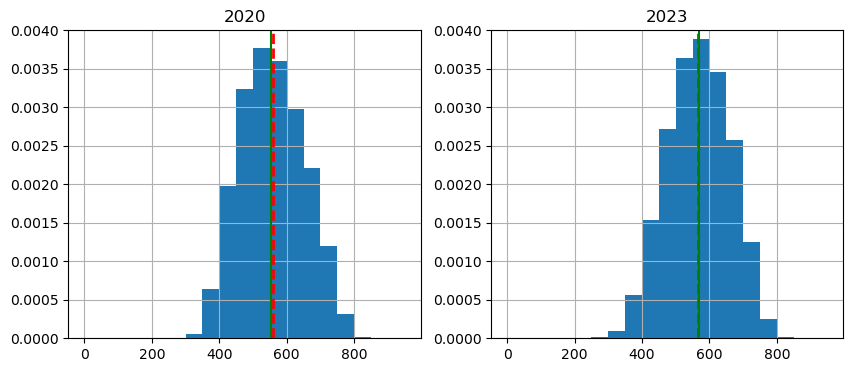

In [63]:
print(f'\n Análise geral Target de 2020 \n {dados2020['TARGET'].describe()}')
print(f'\n Análise geral Target de 2023 \n {dados2023['TARGET'].describe()}')
plt.figure(figsize=(10,4))
bins = range(0,1000,50)
#bins2020=int(len(dados2020['TARGET'])**0.5)
plt.subplot(1,2,1)
plt.hist(dados2020['TARGET'],density=True,bins=bins)
plt.title('2020')
plt.axvline(558.188895, color='red', linestyle='--', label=f'Média: {558.188895:.2f}',linewidth=2)
plt.axvline(554.162500, color='green', linestyle='-', label=f'Mediana: {554.162500:.2f}')
plt.ylim(0,0.004)
plt.grid()
#bins2023=int(len(dados2023['TARGET'])**0.5)
plt.subplot(1,2,2)
plt.hist(dados2023['TARGET'],density=True,bins=bins)
plt.axvline(567.221145, color='red', linestyle='--', label=f'Média: {567.221145:.2f}',linewidth=2)
plt.axvline(568.262500, color='green', linestyle='-', label=f'Mediana: {568.262500:.2f}')
plt.ylim(0,0.004)
plt.title('2023')
plt.grid()

In [61]:
display(dados2020.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).TARGET.describe().round())
display(dados2023.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).TARGET.describe().round())


count   mean   std    min    25%    50%  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                               
Rural              Privada       574.0  591.0  77.0  382.0  537.0  593.0   
                   Pública     13559.0  517.0  88.0  195.0  451.0  510.0   
Urbana             Privada    136038.0  623.0  84.0  228.0  566.0  630.0   
                   Pública    345698.0  534.0  85.0  140.0  471.0  529.0   

                                75%    max  
TP_LOCALIZACAO_ESC TP_ESCOLA                
Rural              Privada    646.0  770.0  
                   Pública    578.0  803.0  
Urbana             Privada    686.0  852.0  
                   Pública    593.0  831.0

count   mean   std    min    25%    50%  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                                   
Rural              Privada           892.0  587.0  84.0  350.0  528.0  593.0   
                   Pública         20892.0  525.0  87.0  131.0  461.0  523.0   
Urbana             Não respondeu       1.0  640.0   NaN  640.0  640.0  640.0   
                   Privada        188227.0  632.0  78.0  218.0  582.0  641.0   
                   Pública        454841.0  542.0  84.0   90.0  483.0  543.0   

                                    75%    max  
TP_LOCALIZACAO_ESC TP_ESCOLA                    
Rural              Privada        652.0  823.0  
                   Pública        589.0  800.0  
Urbana             Não respondeu  640.0  640.0  
                   Privada        690.0  866.0  
                   Pública        602.0  833.0


 Análise geral IFDM de 2020 
 count    495810.000000
mean          0.641443
std           0.128883
min           0.160500
25%           0.549000
50%           0.665100
75%           0.739700
max           0.865600
Name: IFDM, dtype: float64

 Análise geral IFDM de 2023 
 count    664766.000000
mean          0.698458
std           0.120214
min           0.148500
25%           0.620500
50%           0.722400
75%           0.793300
max           0.893200
Name: IFDM, dtype: float64


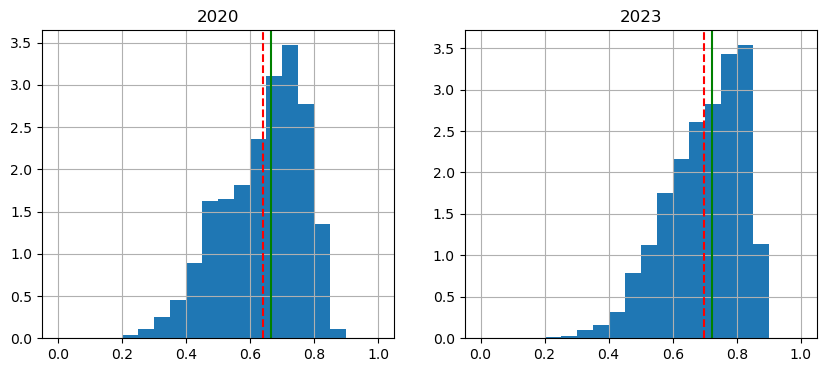

In [47]:
print(f'\n Análise geral IFDM de 2020 \n {dados2020['IFDM'].describe()}')
print(f'\n Análise geral IFDM de 2023 \n {dados2023['IFDM'].describe()}')
plt.figure(figsize=(10,4))
bins = np.linspace(0, 1, 21)
plt.subplot(1,2,1)
plt.hist(dados2020['IFDM'],density=True,bins=bins)
plt.axvline(0.641443, color='red', linestyle='--', label=f'Média: {0.641443:.2f}')
plt.axvline(0.665100, color='green', linestyle='-', label=f'Mediana: {0.665100:.2f}')
plt.title('2020')
plt.grid()
plt.subplot(1,2,2)
plt.hist(dados2023['IFDM'],density=True,bins=bins)
plt.axvline(0.698458, color='red', linestyle='--', label=f'Média: {0.698458:.2f}')
plt.axvline(0.722400, color='green', linestyle='-', label=f'Mediana: {0.722400:.2f}')
plt.title('2023')
plt.grid()

In [70]:
display(dados2020.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).IFDM.describe().round(3))
display(dados2023.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).IFDM.describe().round(3))

count   mean    std    min    25%    50%  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                                
Rural              Privada       574.0  0.633  0.131  0.256  0.513  0.694   
                   Pública     13551.0  0.540  0.130  0.160  0.448  0.526   
Urbana             Privada    136038.0  0.692  0.104  0.240  0.631  0.717   
                   Pública    345647.0  0.626  0.131  0.194  0.528  0.642   

                                75%    max  
TP_LOCALIZACAO_ESC TP_ESCOLA                
Rural              Privada    0.738  0.850  
                   Pública    0.635  0.866  
Urbana             Privada    0.781  0.866  
                   Pública    0.734  0.866

count   mean    std    min    25%    50%  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                                    
Rural              Privada           892.0  0.682  0.122  0.325  0.577  0.744   
                   Pública         20864.0  0.605  0.124  0.158  0.522  0.603   
Urbana             Não respondeu       1.0  0.529    NaN  0.529  0.529  0.529   
                   Privada        188227.0  0.745  0.095  0.247  0.678  0.767   
                   Pública        454782.0  0.683  0.123  0.148  0.598  0.693   

                                    75%    max  
TP_LOCALIZACAO_ESC TP_ESCOLA                    
Rural              Privada        0.784  0.868  
                   Pública        0.697  0.876  
Urbana             Não respondeu  0.529  0.529  
                   Privada        0.827  0.888  
                   Pública        0.786  0.893


 Análise geral PIB de 2020 
 count    495869.00000
mean      36738.17493
std       27602.04497
min        4920.64000
25%       20407.26000
50%       29935.42000
75%       49122.79000
max      590594.94000
Name: PIB_MUNICIPAL_PER_CAPITA, dtype: float64

 Análise geral PIB de 2023 
 count    664853.000000
mean      54752.529729
std       44789.893803
min        7201.700000
25%       29205.900000
50%       44563.380000
75%       69460.170000
max      722441.520000
Name: PIB_MUNICIPAL_PER_CAPITA, dtype: float64


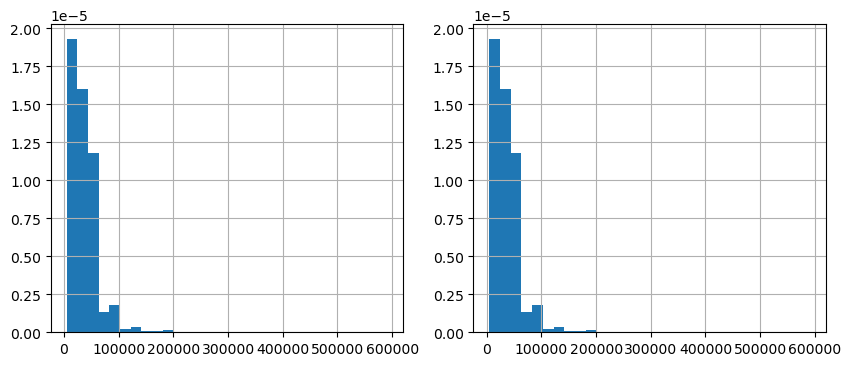

In [ ]:
print(f'\n Análise geral PIB de 2020 \n {dados2020['PIB_MUNICIPAL_PER_CAPITA'].describe()}')
print(f'\n Análise geral PIB de 2023 \n {dados2023['PIB_MUNICIPAL_PER_CAPITA'].describe()}')
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(dados2020['PIB_MUNICIPAL_PER_CAPITA'],density=True,bins=30)
plt.axvline(0.698458, color='red', linestyle='--', label=f'Média: {0.698458:.2f}')
plt.axvline(0.722400, color='green', linestyle='-', label=f'Mediana: {0.722400:.2f}')
plt.grid()
plt.subplot(1,2,2)
plt.hist(dados2020['PIB_MUNICIPAL_PER_CAPITA'],density=True,bins=30)
plt.grid()

In [79]:
dados2023.sort_values('PIB_MUNICIPAL_PER_CAPITA', ascending=False).PIB_MUNICIPAL_PER_CAPITA.unique()[:20]

array([722441.52, 684319.23, 679714.48, 606740.73, 537982.68, 424535.26,
       409443.67, 388732.46, 382417.42, 377790.63, 369126.5 , 362455.53,
       348422.72, 335620.33, 330535.28, 330080.63, 329299.37, 325175.25,
       320476.29, 317824.61])

In [73]:
dados2023.sort_values('PIB_MUNICIPAL_PER_CAPITA', ascending=False).head(5)

,Unnamed: 0,TP_SEXO,TP_COR_RACA,TP_ESCOLA,MUNICIPIO_ESCOLARIDADE,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,...,Q019,Q020,Q021,Q022,Q023,Q024,Q025,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
350724,350724,F,Branca,Pública,330550,Saquarema,33.0,RJ,Estadual,Urbana,...,2,Não,Não,4+,Não,Não,Sim,541.2325,722441.52,0.6389
154094,154094,F,Parda,Privada,330550,Saquarema,33.0,RJ,Privada,Urbana,...,1,Sim,Não,2,Não,1,Sim,542.6575,722441.52,0.6389
662662,662662,F,Branca,Pública,330550,Saquarema,33.0,RJ,Estadual,Urbana,...,1,Não,Não,2,Não,Não,Sim,537.2375,722441.52,0.6389
353926,353926,F,Branca,Pública,330550,Saquarema,33.0,RJ,Estadual,Urbana,...,1,Não,Sim,4+,Não,1,Sim,633.5800,722441.52,0.6389
555385,555385,M,Branca,Pública,330550,Saquarema,33.0,RJ,Estadual,Urbana,...,1,Não,Sim,3,Não,1,Sim,378.1100,722441.52,0.6389


In [71]:
display(dados2020.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).PIB_MUNICIPAL_PER_CAPITA.describe().round(3))
display(dados2023.groupby(['TP_LOCALIZACAO_ESC','TP_ESCOLA']).PIB_MUNICIPAL_PER_CAPITA.describe().round(3))

count       mean        std      min  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                            
Rural              Privada       574.0  51722.565  47137.746  6342.85   
                   Pública     13559.0  25880.716  23406.765  5558.67   
Urbana             Privada    136038.0  41888.654  25281.047  6384.75   
                   Pública    345698.0  35112.347  28250.203  4920.64   

                                   25%       50%       75%        max  
TP_LOCALIZACAO_ESC TP_ESCOLA                                           
Rural              Privada    20302.19  40058.99  69950.95  310898.86  
                   Pública    11427.01  17729.65  31290.27  295506.92  
Urbana             Privada    24740.43  38691.55  51050.94  590594.94  
                   Pública    18049.58  28420.87  45595.65  590594.94

count       mean         std       min  \
TP_LOCALIZACAO_ESC TP_ESCOLA                                                  
Rural              Privada           892.0  73410.792  101789.696  11284.69   
                   Pública         20892.0  37825.564   38381.309   7701.32   
Urbana             Não respondeu       1.0  13890.130         NaN  13890.13   
                   Privada        188227.0  63377.270   40413.149   9604.74   
                   Pública        454841.0  51924.348   45999.559   7201.70   

                                       25%       50%       75%        max  
TP_LOCALIZACAO_ESC TP_ESCOLA                                               
Rural              Privada        30640.46  50310.32  78144.03  679714.48  
                   Pública        16141.60  26617.09  45271.91  722441.52  
Urbana             Não respondeu  13890.13  13890.13  13890.13   13890.13  
                   Privada        36449.37  57528.91  78586.94  722441.52  
                   Pública        25497.43  41477.50  67371.97  722441.52

SEA BORN: Biblioteca que produz gráficos esteticamente melhores e riqueza de informações (y,x,hue)

SPEARMAN: Correlação para variáveis quali ordinais